In [39]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Setting style visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimport!")

Library berhasil diimport!


In [40]:
# MEMUAT DATASET
print("="*50)
print("TAHAP 1: MEMUAT DATA")
print("="*50)

# Load dataset Titanic dari seaborn
df = sns.load_dataset("titanic")

print("Data Titanic berhasil dimuat!")
print(f"Ukuran data awal: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\n5 data teratas:")
df.head()

TAHAP 1: MEMUAT DATA
Data Titanic berhasil dimuat!
Ukuran data awal: 891 baris, 15 kolom

5 data teratas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
# TUGAS 1: MENAMPILKAN UKURAN DATA DAN TIPE KOLOM
print("="*50)
print("TUGAS 1: UKURAN DATA DAN TIPE KOLOM")
print("="*50)

# Ukuran data
print(f" Ukuran dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print("-" * 30)

# Tipe data setiap kolom
print(" Tipe data setiap kolom:")
print(df.dtypes)
print("-" * 30)

# Informasi lengkap
print(" Informasi lengkap data:")
df.info()

TUGAS 1: UKURAN DATA DAN TIPE KOLOM
 Ukuran dataset: 891 baris × 15 kolom
------------------------------
 Tipe data setiap kolom:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
------------------------------
 Informasi lengkap data:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6

TAHAP 2: CEK MISSING VALUE AWAL
Kolom dengan missing value:
             Jumlah Missing  Persentase (%)
age                     177           19.87
embarked                  2            0.22
deck                    688           77.22
embark_town               2            0.22


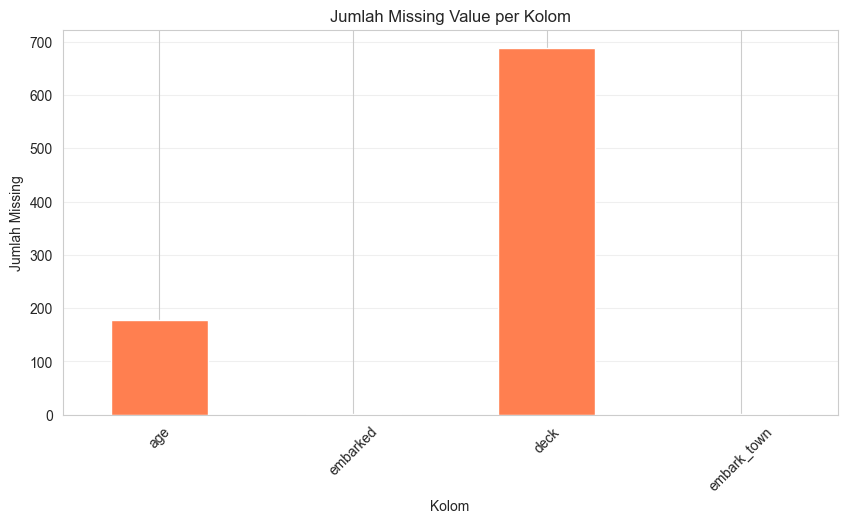

In [42]:
# CEK MISSING VALUE AWAL
print("="*50)
print("TAHAP 2: CEK MISSING VALUE AWAL")
print("="*50)

missing_awal = df.isnull().sum()
missing_percent = (missing_awal / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_awal,
    'Persentase (%)': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

print("Kolom dengan missing value:")
print(missing_df)

# Visualisasi missing value
plt.figure(figsize=(10, 5))
missing_df['Jumlah Missing'].plot(kind='bar', color='coral')
plt.title('Jumlah Missing Value per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [43]:
# TUGAS 2: PENANGANAN MISSING VALUE
print("="*50)
print("TUGAS 2: HANDLING MISSING VALUE")
print("="*50)

# ALASAN PENANGANAN:
# - age: diisi MEDIAN karena distribusi umur skewed (tidak normal)
# - embarked: diisi MODUS karena kategorikal, hanya 2 data hilang
# - embark_town: diisi MODUS (sama dengan embarked)
# - deck: DIHAPUS karena 77% data hilang, tidak representatif

# Menangani missing value
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Hapus kolom deck karena terlalu banyak missing
df = df.drop(columns=['deck'])

print(" Missing value pada 'age' diisi dengan MEDIAN")
print(" Missing value pada 'embarked' diisi dengan MODUS")
print(" Missing value pada 'embark_town' diisi dengan MODUS")
print(" Kolom 'deck' dihapus (77% data hilang)")

# Cek hasil
print("\n Cek missing value setelah penanganan:")
print(df.isnull().sum().sum(), "missing value tersisa (0 berarti bersih)")

TUGAS 2: HANDLING MISSING VALUE
 Missing value pada 'age' diisi dengan MEDIAN
 Missing value pada 'embarked' diisi dengan MODUS
 Missing value pada 'embark_town' diisi dengan MODUS
 Kolom 'deck' dihapus (77% data hilang)

 Cek missing value setelah penanganan:
0 missing value tersisa (0 berarti bersih)


In [44]:
# TUGAS 3: DETEKSI OUTLIER
print("="*50)
print("TUGAS 3: DETEKSI OUTLIER")
print("="*50)

# Fungsi deteksi outlier
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Deteksi outlier pada 'fare'
n_fare, low_fare, high_fare = detect_outliers_iqr(df, 'fare')
print(f"\n Kolom 'fare' (harga tiket):")
print(f"   - Jumlah outlier: {n_fare} data ({n_fare/len(df)*100:.1f}%)")
print(f"   - Batas bawah: Rp{low_fare:.2f}")
print(f"   - Batas atas: Rp{high_fare:.2f}")

# Deteksi outlier pada 'age'
n_age, low_age, high_age = detect_outliers_iqr(df, 'age')
print(f"\n Kolom 'age' (usia):")
print(f"   - Jumlah outlier: {n_age} data ({n_age/len(df)*100:.1f}%)")
print(f"   - Batas bawah: {low_age:.1f} tahun")
print(f"   - Batas atas: {high_age:.1f} tahun")

TUGAS 3: DETEKSI OUTLIER

 Kolom 'fare' (harga tiket):
   - Jumlah outlier: 116 data (13.0%)
   - Batas bawah: Rp-26.72
   - Batas atas: Rp65.63

 Kolom 'age' (usia):
   - Jumlah outlier: 66 data (7.4%)
   - Batas bawah: 2.5 tahun
   - Batas atas: 54.5 tahun


VISUALISASI OUTLIER SEBELUM HANDLING


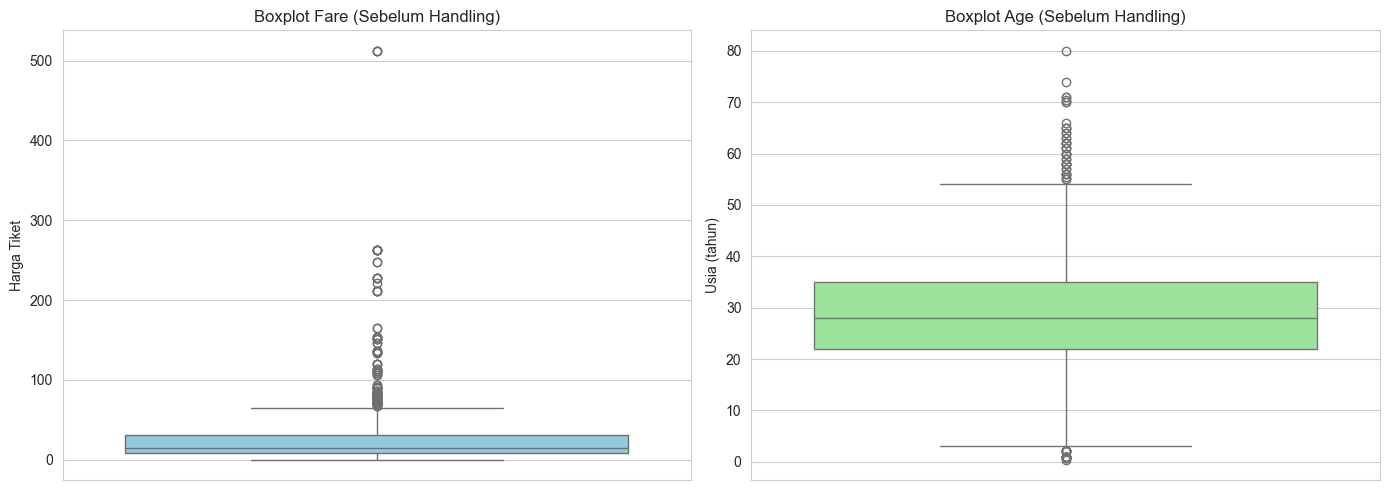

 Terlihat banyak outlier di kedua kolom, terutama 'fare'.


In [45]:
# VISUALISASI OUTLIER SEBELUM HANDLING
print("="*50)
print("VISUALISASI OUTLIER SEBELUM HANDLING")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot fare
sns.boxplot(y=df['fare'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot Fare (Sebelum Handling)', fontsize=12)
axes[0].set_ylabel('Harga Tiket')

# Boxplot age
sns.boxplot(y=df['age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Age (Sebelum Handling)', fontsize=12)
axes[1].set_ylabel('Usia (tahun)')

plt.tight_layout()
plt.show()

print(" Terlihat banyak outlier di kedua kolom, terutama 'fare'.")

In [46]:
# HANDLING OUTLIER DENGAN CLIPPING
print("="*50)
print("HANDLING OUTLIER: METODE CLIPPING")
print("="*50)

# ALASAN: Clipping dipilih agar data tidak berkurang, 
# namun nilai ekstrim tetap dibatasi.

# Hitung ulang batas IQR
Q1_fare, Q3_fare = df['fare'].quantile(0.25), df['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
low_fare = Q1_fare - 1.5 * IQR_fare
high_fare = Q3_fare + 1.5 * IQR_fare

Q1_age, Q3_age = df['age'].quantile(0.25), df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
low_age = Q1_age - 1.5 * IQR_age
high_age = Q3_age + 1.5 * IQR_age

# Lakukan clipping
df['fare'] = df['fare'].clip(low_fare, high_fare)
df['age'] = df['age'].clip(low_age, high_age)

print(" Outlier pada 'fare' telah di-clip")
print(" Outlier pada 'age' telah di-clip")
print("\n   Rentang baru fare: [{:.2f} - {:.2f}]".format(low_fare, high_fare))
print("   Rentang baru age: [{:.1f} - {:.1f}]".format(low_age, high_age))

HANDLING OUTLIER: METODE CLIPPING
 Outlier pada 'fare' telah di-clip
 Outlier pada 'age' telah di-clip

   Rentang baru fare: [-26.72 - 65.63]
   Rentang baru age: [2.5 - 54.5]


VISUALISASI OUTLIER SETELAH HANDLING


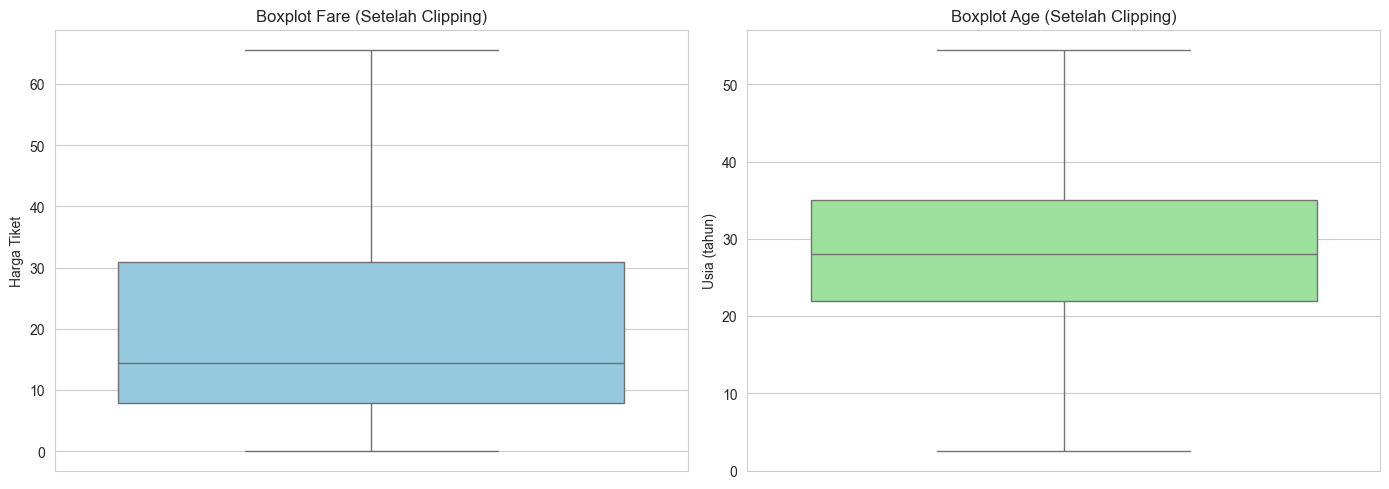

 Outlier sudah berkurang signifikan, data lebih rapi.


In [47]:
# VISUALISASI OUTLIER SETELAH HANDLING
print("="*50)
print("VISUALISASI OUTLIER SETELAH HANDLING")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot fare setelah clipping
sns.boxplot(y=df['fare'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot Fare (Setelah Clipping)', fontsize=12)
axes[0].set_ylabel('Harga Tiket')

# Boxplot age setelah clipping
sns.boxplot(y=df['age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Age (Setelah Clipping)', fontsize=12)
axes[1].set_ylabel('Usia (tahun)')

plt.tight_layout()
plt.show()

print(" Outlier sudah berkurang signifikan, data lebih rapi.")

In [48]:
# TUGAS 4: SCALING DATA
print("="*50)
print("TUGAS 4: SCALING DATA NUMERIK")
print("="*50)

# Pilih kolom numerik
numerical_cols = ['age', 'fare', 'sibsp', 'parch']

print(" Kolom yang akan di-scale:")
for col in numerical_cols:
    print(f"   - {col}")

# Statistik sebelum scaling
print("\n Statistik SEBELUM scaling:")
print(df[numerical_cols].describe().round(2))

# Lakukan StandardScaler
# ALASAN: StandardScaler cocok untuk algoritma yang mengasumsikan distribusi normal
# dan membuat semua fitur memiliki skala yang sama (mean=0, std=1)

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("\n Scaling dengan StandardScaler selesai!")
print("\n Statistik SETELAH scaling:")
print(df_scaled[numerical_cols].describe().round(2))

TUGAS 4: SCALING DATA NUMERIK
 Kolom yang akan di-scale:
   - age
   - fare
   - sibsp
   - parch

 Statistik SEBELUM scaling:
          age    fare   sibsp   parch
count  891.00  891.00  891.00  891.00
mean    29.04   24.05    0.52    0.38
std     12.07   20.48    1.10    0.81
min      2.50    0.00    0.00    0.00
25%     22.00    7.91    0.00    0.00
50%     28.00   14.45    0.00    0.00
75%     35.00   31.00    1.00    0.00
max     54.50   65.63    8.00    6.00

 Scaling dengan StandardScaler selesai!

 Statistik SETELAH scaling:
          age    fare   sibsp   parch
count  891.00  891.00  891.00  891.00
mean     0.00    0.00    0.00    0.00
std      1.00    1.00    1.00    1.00
min     -2.20   -1.17   -0.47   -0.47
25%     -0.58   -0.79   -0.47   -0.47
50%     -0.09   -0.47   -0.47   -0.47
75%      0.49    0.34    0.43   -0.47
max      2.11    2.03    6.78    6.97


VISUALISASI SEBELUM VS SESUDAH SCALING


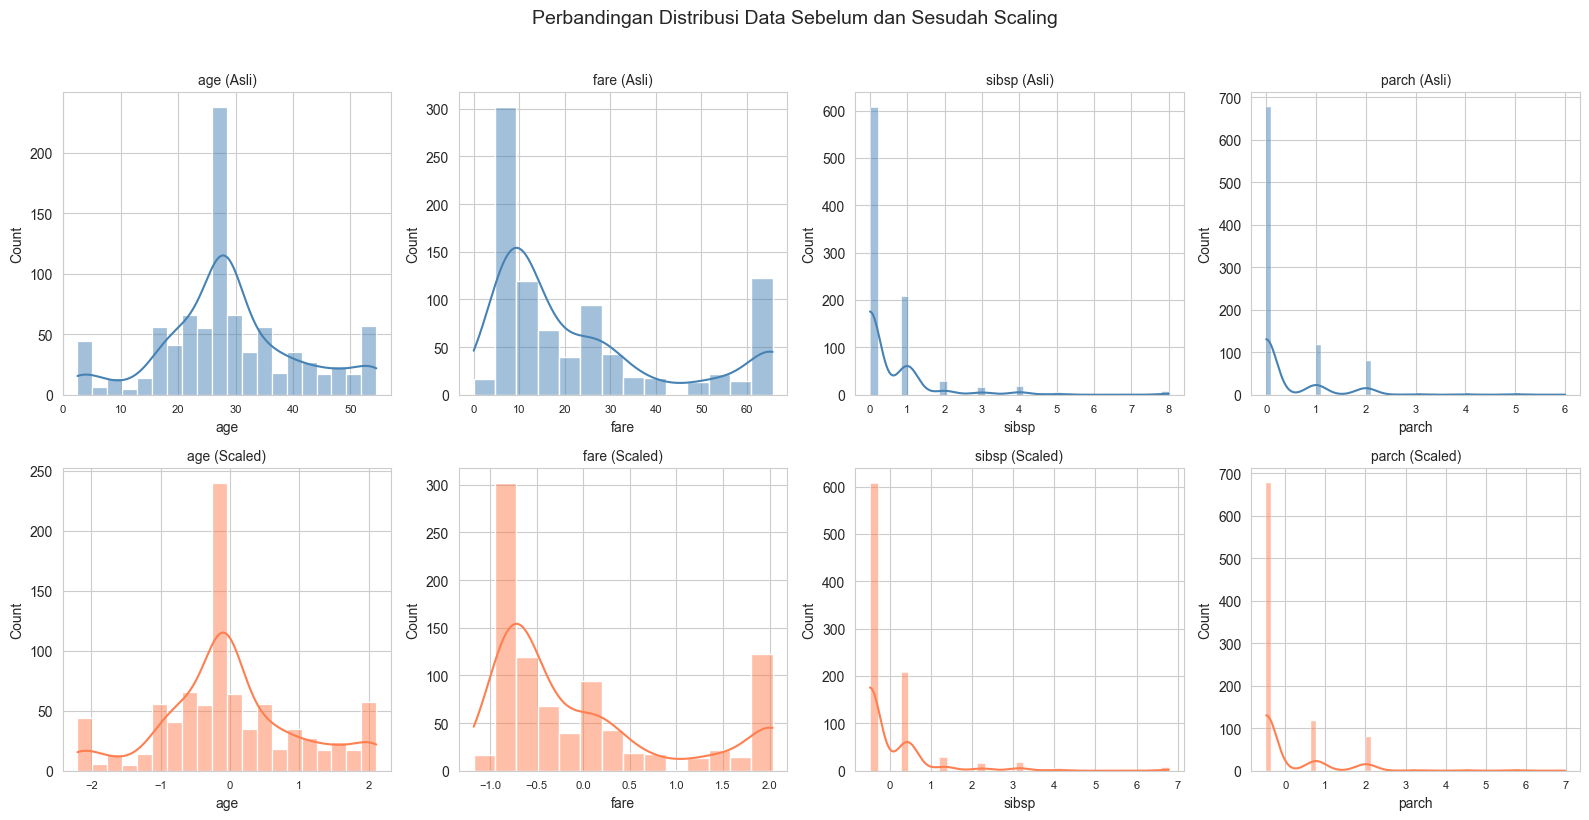

 Setelah scaling, semua data memiliki rentang yang seragam.


In [49]:
# VISUALISASI PERBANDINGAN SCALING
print("="*50)
print("VISUALISASI SEBELUM VS SESUDAH SCALING")
print("="*50)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(numerical_cols):
    # Baris atas: sebelum scaling
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} (Asli)', fontsize=10)
    axes[0, i].tick_params(axis='x', labelsize=8)
    
    # Baris bawah: setelah scaling
    sns.histplot(df_scaled[col], kde=True, ax=axes[1, i], color='coral')
    axes[1, i].set_title(f'{col} (Scaled)', fontsize=10)
    axes[1, i].tick_params(axis='x', labelsize=8)

plt.suptitle('Perbandingan Distribusi Data Sebelum dan Sesudah Scaling', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(" Setelah scaling, semua data memiliki rentang yang seragam.")

VISUALISASI 1: DISTRIBUSI TARGET (SURVIVED)


C:\Users\ferdi\AppData\Local\Temp\ipykernel_8672\1769400320.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='survived', data=df, palette=['#FF6B6B', '#4ECDC4'])


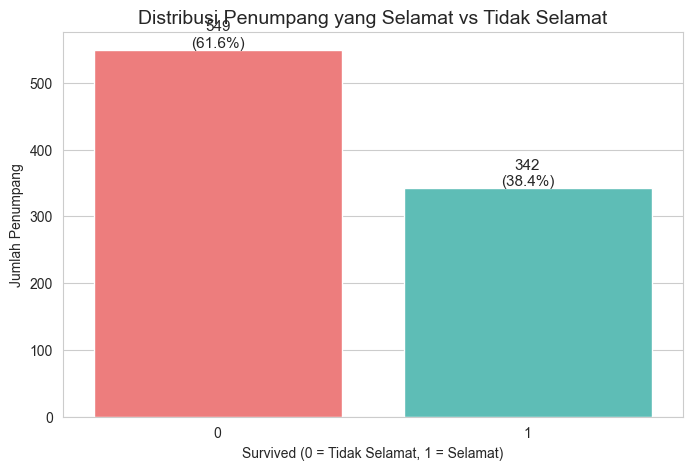


 INSIGHT 1:
   Dari total 891 penumpang, hanya 342 orang (38.4%) yang selamat,
   sedangkan 549 orang (61.6%) meninggal. Ini menunjukkan bahwa
   data target tidak seimbang (imbalanced), yang perlu diperhatikan
   saat memilih metrik evaluasi model nantinya.


In [ ]:
# TUGAS 5: VISUALISASI 1 - DISTRIBUSI TARGET
print("="*50)
print("VISUALISASI 1: DISTRIBUSI TARGET (SURVIVED)")
print("="*50)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='survived', data=df, palette=['#FF6B6B', '#4ECDC4'])

# Tambah angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.title('Distribusi Penumpang yang Selamat vs Tidak Selamat', fontsize=14)
plt.xlabel('Survived (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.show()

VISUALISASI 2: DISTRIBUSI UMUR PENUMPANG


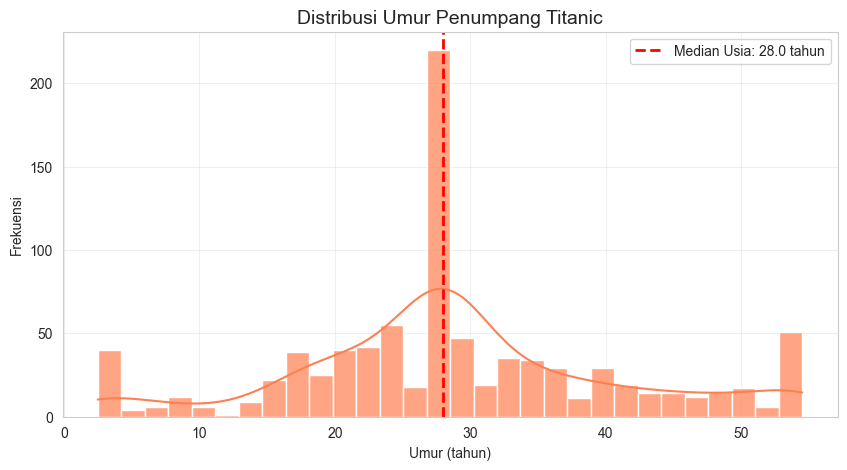


 INSIGHT 2:
   Distribusi umur penumpang cukup lebar (0-70 tahun) dengan konsentrasi
   terbanyak pada usia dewasa muda (20-35 tahun). Median umur adalah
   28.0 tahun. Ada juga cukup banyak anak-anak (0-10 tahun)
   yang menunjukkan banyak keluarga ikut dalam perjalanan ini.


In [ ]:
# VISUALISASI 2: DISTRIBUSI UMUR
print("="*50)
print("VISUALISASI 2: DISTRIBUSI UMUR PENUMPANG")
print("="*50)

plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='coral', alpha=0.7)

# Tambah garis median
median_age = df['age'].median()
plt.axvline(median_age, color='red', linestyle='--', linewidth=2, 
            label=f'Median Usia: {median_age:.1f} tahun')

plt.title('Distribusi Umur Penumpang Titanic', fontsize=14)
plt.xlabel('Umur (tahun)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

VISUALISASI 3: KELAS PENUMPANG VS TINGKAT KESELAMATAN


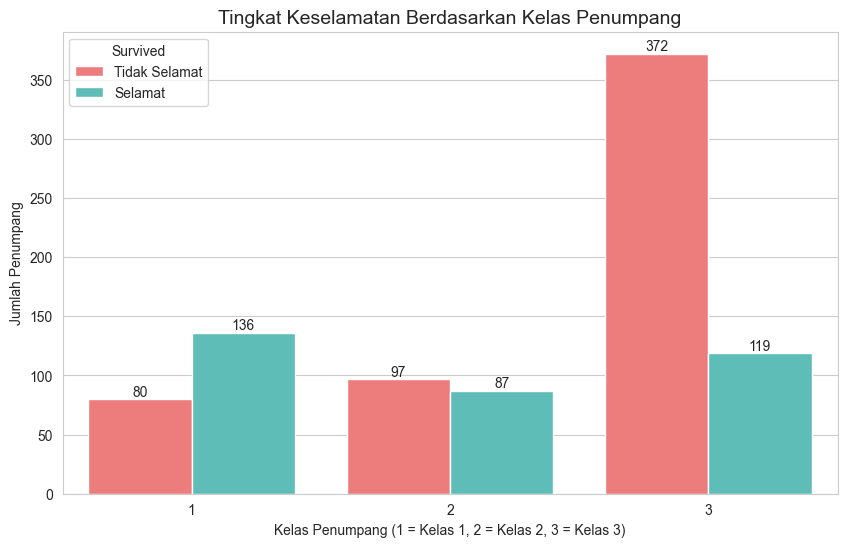


 INSIGHT 3:
   Kelas sosial sangat menentukan keselamatan:
   • Kelas 1: 136 selamat (63%) vs 80 tidak selamat (37%)
   • Kelas 2: 87 selamat (47%) vs 97 tidak selamat (53%)
   • Kelas 3: 119 selamat (24%) vs 372 tidak selamat (76%)
   Ini mencerminkan prioritas evakuasi 'women and children first'
   yang lebih mudah diakses penumpang kelas atas.


In [ ]:
# VISUALISASI 3: KELAS PENUMPANG VS KESELAMATAN
print("="*50)
print("VISUALISASI 3: KELAS PENUMPANG VS TINGKAT KESELAMATAN")
print("="*50)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='pclass', hue='survived', data=df, 
                   palette=['#FF6B6B', '#4ECDC4'])

# Tambah angka di atas bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width()/2., height), 
                    ha='center', va='bottom', fontsize=10)

plt.title('Tingkat Keselamatan Berdasarkan Kelas Penumpang', fontsize=14)
plt.xlabel('Kelas Penumpang (1 = Kelas 1, 2 = Kelas 2, 3 = Kelas 3)')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Survived', labels=['Tidak Selamat', 'Selamat'])
plt.show()

VISUALISASI 4: JENIS KELAMIN VS TINGKAT KESELAMATAN


<Figure size 800x500 with 0 Axes>

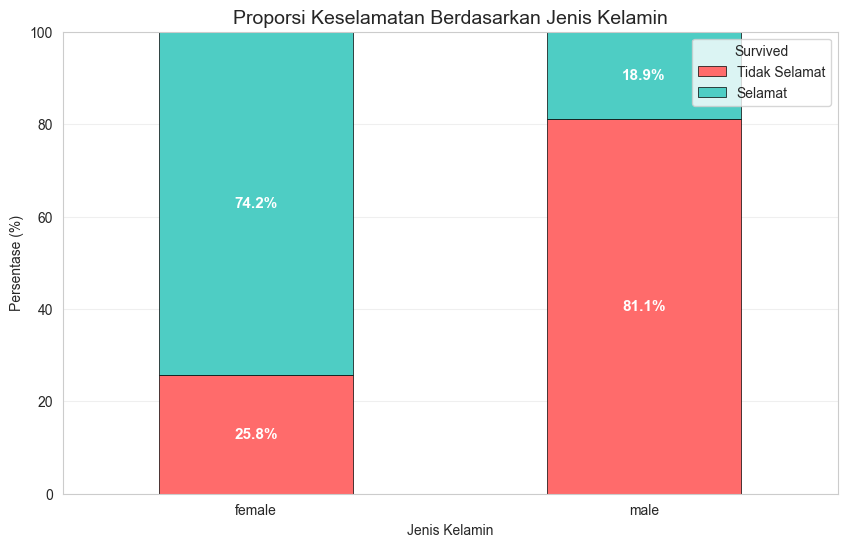


 INSIGHT 4:
   Prinsip 'women and children first' sangat terlihat jelas:
   • Wanita: 74.2% selamat, hanya 25.8% tidak selamat
   • Pria: 18.9% selamat, 81.1% tidak selamat
   Jenis kelamin adalah faktor TERKUAT dalam menentukan keselamatan,
   dengan peluang selamat wanita 4x lebih tinggi dibanding pria.


In [ ]:
# VISUALISASI 4: JENIS KELAMIN VS KESELAMATAN
print("="*50)
print("VISUALISASI 4: JENIS KELAMIN VS TINGKAT KESELAMATAN")
print("="*50)

# Buat cross tabulasi dengan persentase
survived_sex = pd.crosstab(df['sex'], df['survived'], normalize='index') * 100

plt.figure(figsize=(8, 5))
ax = survived_sex.plot(kind='bar', stacked=True, 
                       color=['#FF6B6B', '#4ECDC4'], 
                       edgecolor='black', linewidth=0.5)

# Tambah label persentase
for i, (index, row) in enumerate(survived_sex.iterrows()):
    for j, value in enumerate(row):
        if value > 0:
            plt.text(i, row[:j].sum() + value/2, f'{value:.1f}%', 
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if value > 10 else 'black')

plt.title('Proporsi Keselamatan Berdasarkan Jenis Kelamin', fontsize=14)
plt.xlabel('Jenis Kelamin')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Survived', labels=['Tidak Selamat', 'Selamat'], 
           loc='upper right')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

VISUALISASI 5: HEATMAP KORELASI


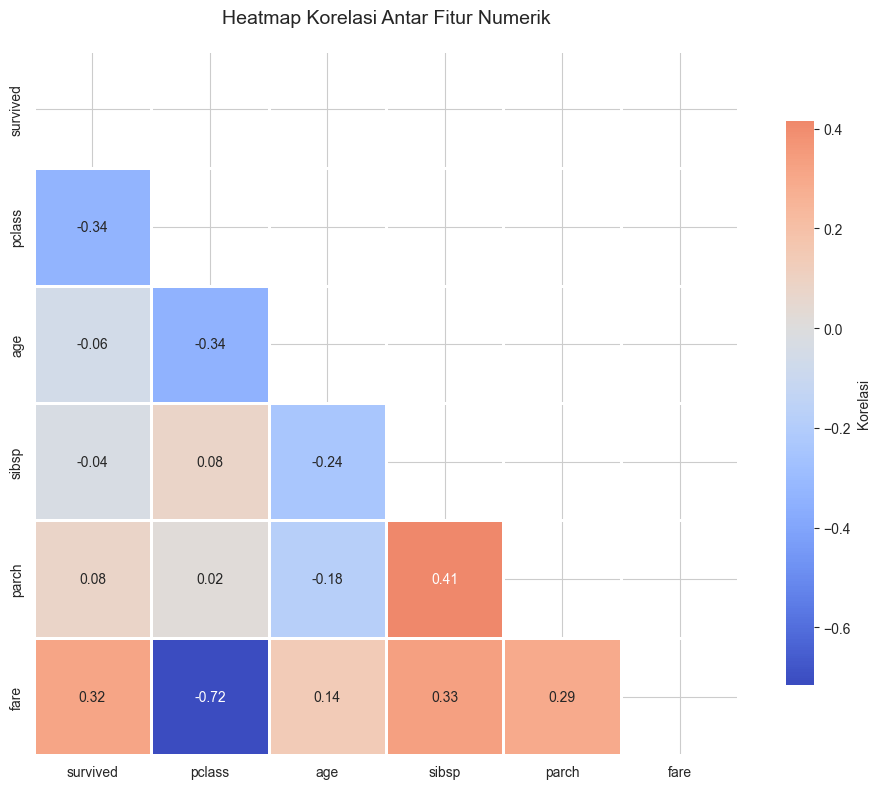


 INSIGHT 5:
   Korelasi dengan target 'survived':
   • pclass (-0.34): Semakin tinggi kelas (1=tertinggi), makin besar peluang selamat
   • fare (+0.26): Penumpang bayar tiket mahal cenderung selamat
   • age (-0.06): Korelasi lemah, umur tidak terlalu berpengaruh
   • sibsp/parch: Korelasi sangat lemah dengan keselamatan
   
   Korelasi antar fitur:
   • pclass vs fare (-0.55): Kelas tinggi bayar tiket mahal
   • sibsp vs parch (+0.41): Bepergian dengan pasangan/anak juga cenderung bawa orang tua


In [ ]:
# VISUALISASI 5: HEATMAP KORELASI FITUR NUMERIK
print("="*50)
print("VISUALISASI 5: HEATMAP KORELASI")
print("="*50)

# Pilih kolom numerik relevan
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk segitiga atas
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, mask=mask,
            cbar_kws={'shrink': 0.8, 'label': 'Korelasi'})

plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

VISUALISASI TAMBAHAN: PAIRPLOT


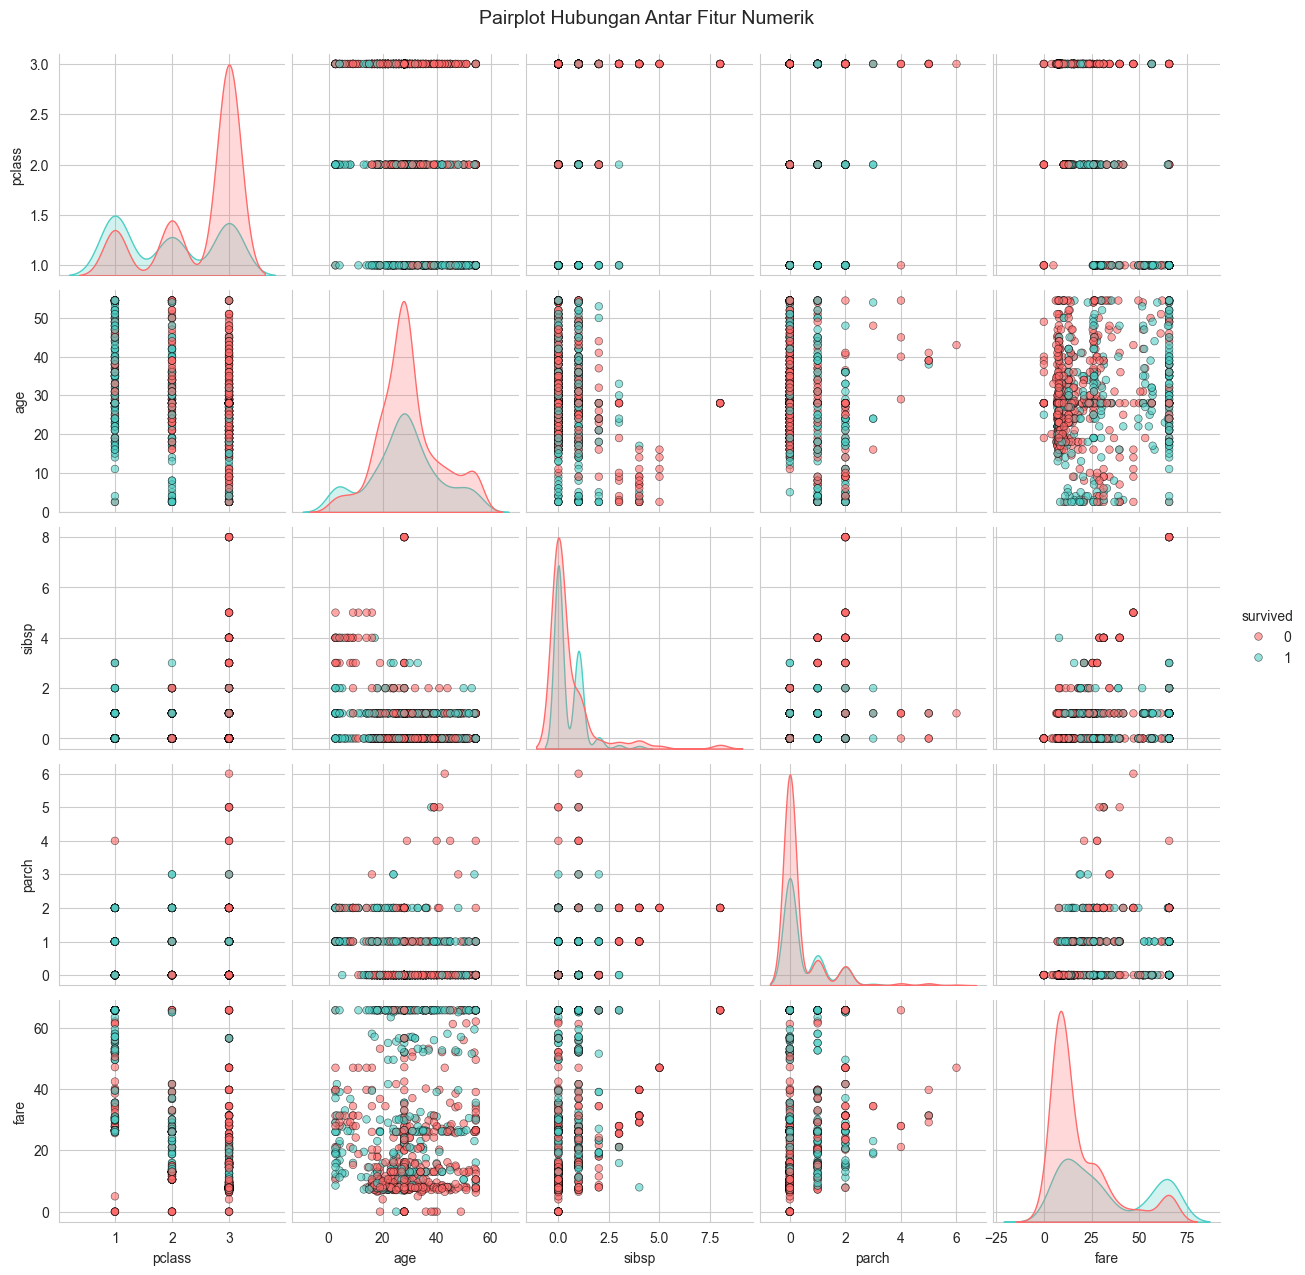

 Pairplot membantu melihat pola hubungan antar fitur secara visual.


In [55]:
# VISUALISASI TAMBAHAN: PAIRPLOT
print("="*50)
print("VISUALISASI TAMBAHAN: PAIRPLOT")
print("="*50)

# Pairplot untuk melihat hubungan antar fitur
sns.pairplot(df[numeric_cols], hue='survived', 
             diag_kind='kde', palette=['#FF6B6B', '#4ECDC4'],
             plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
plt.suptitle('Pairplot Hubungan Antar Fitur Numerik', y=1.02, fontsize=14)
plt.show()

print(" Pairplot membantu melihat pola hubungan antar fitur secara visual.")

In [56]:
# CEK DATA FINAL
print("="*50)
print("DATA FINAL SETELAH PREPROCESSING")
print("="*50)

print(f"Ukuran data akhir: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\n5 data teratas (data asli - sudah dibersihkan):")
df.head()

print("\n5 data teratas (data sudah di-scale):")
df_scaled.head()

DATA FINAL SETELAH PREPROCESSING
Ukuran data akhir: 891 baris, 14 kolom

5 data teratas (data asli - sudah dibersihkan):

5 data teratas (data sudah di-scale):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.583432,0.432793,-0.473674,-0.820552,S,Third,man,True,Southampton,no,False
1,1,1,female,0.742685,0.432793,-0.473674,2.031623,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,-0.251903,-0.474545,-0.473674,-0.787578,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.494038,0.432793,-0.473674,1.419297,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.494038,-0.474545,-0.473674,-0.781471,S,Third,man,True,Southampton,no,True
